<a href="https://colab.research.google.com/github/TanviAshokKadge/DS/blob/main/TCS2526025_Tanvi_Ashok_Kadge_DS_Pract_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv('/content/PCOS_data.csv')
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [ ]:
# Check null values
df.isnull().sum()

,0
Sl. No,0
Patient File No.,0
PCOS (Y/N),0
Age (yrs),0
Weight (Kg),0
Height(Cm),0
BMI,0
Blood Group,0
Pulse rate(bpm),0
RR (breaths/min),0


In [ ]:
# Converting categorical to numeric and filling missing values

df['PCOS (Y/N)'] = df['PCOS (Y/N)'].astype(int)
df.fillna(df.mean(), inplace=True)

TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

In [ ]:
df.describe()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,...,541.000000,540.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,271.000000,271.000000,0.327172,31.430684,59.637153,156.484835,24.307579,13.802218,73.247689,19.243993,...,0.489834,0.514815,0.247689,114.661738,76.927911,6.129390,6.641405,15.018115,15.451701,8.475915
std,156.317519,156.317519,0.469615,5.411006,11.028287,6.033545,4.055129,1.840812,4.430285,1.688629,...,0.500359,0.500244,0.432070,7.384556,5.574112,4.229294,4.436889,3.566839,3.318848,2.165381
min,1.000000,1.000000,0.000000,20.000000,31.000000,137.000000,12.400000,11.000000,13.000000,16.000000,...,0.000000,0.000000,0.000000,12.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,136.000000,136.000000,0.000000,28.000000,52.000000,152.000000,21.600000,13.000000,72.000000,18.000000,...,0.000000,0.000000,0.000000,110.000000,70.000000,3.000000,3.000000,13.000000,13.000000,7.000000
50%,271.000000,271.000000,0.000000,31.000000,59.000000,156.000000,24.200000,14.000000,72.000000,18.000000,...,0.000000,1.000000,0.000000,110.000000,80.000000,5.000000,6.000000,15.000000,16.000000,8.500000
75%,406.000000,406.000000,1.000000,35.000000,65.000000,160.000000,26.600000,15.000000,74.000000,20.000000,...,1.000000,1.000000,0.000000,120.000000,80.000000,9.000000,10.000000,18.000000,18.000000,9.800000
max,541.000000,541.000000,1.000000,48.000000,108.000000,180.000000,38.900000,18.000000,82.000000,28.000000,...,1.000000,1.000000,1.000000,140.000000,100.000000,22.000000,20.000000,24.000000,24.000000,18.000000


/tmp/ipykernel_175/4001202693.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PCOS (Y/N)', data=df, palette='pastel')


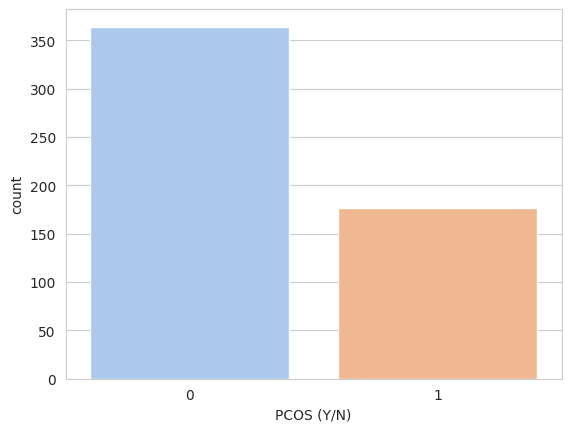

In [ ]:
sns.countplot(x='PCOS (Y/N)', data=df, palette='pastel')
plt.show()

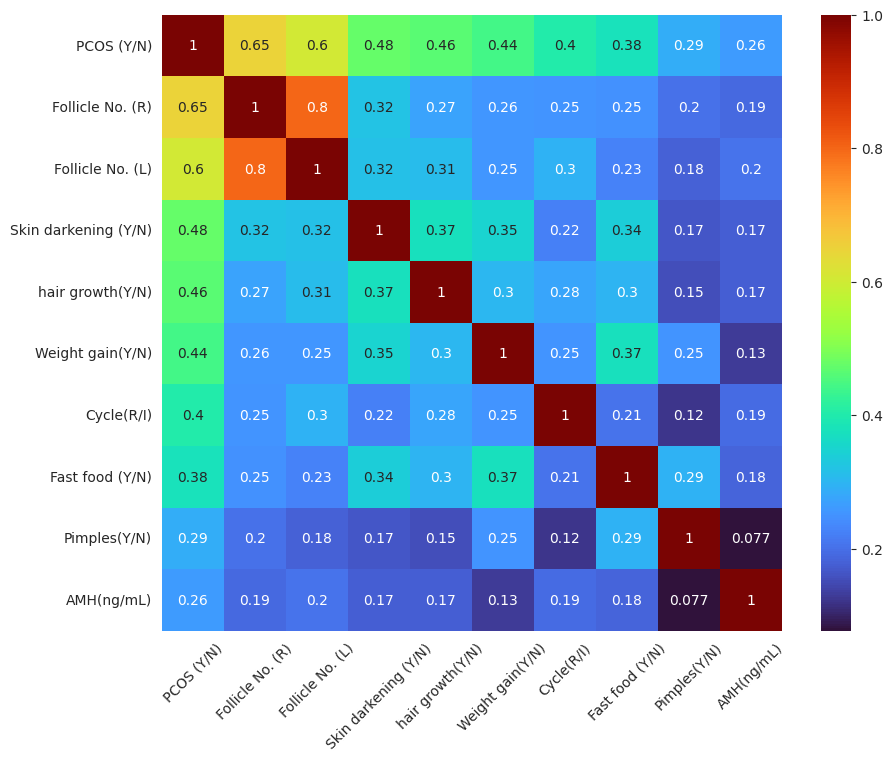

In [ ]:
# Convert all columns to numeric safely
df = df.apply(pd.to_numeric, errors='coerce')

# Fill missing values
df.fillna(df.mean(), inplace=True)

corr = df.corr()
top = corr['PCOS (Y/N)'].abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(10,8))
sns.heatmap(df[top].corr(), cmap='turbo', annot=True)

plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_175/3263392337.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PCOS (Y/N)', y='BMI', data=df, palette='magma')


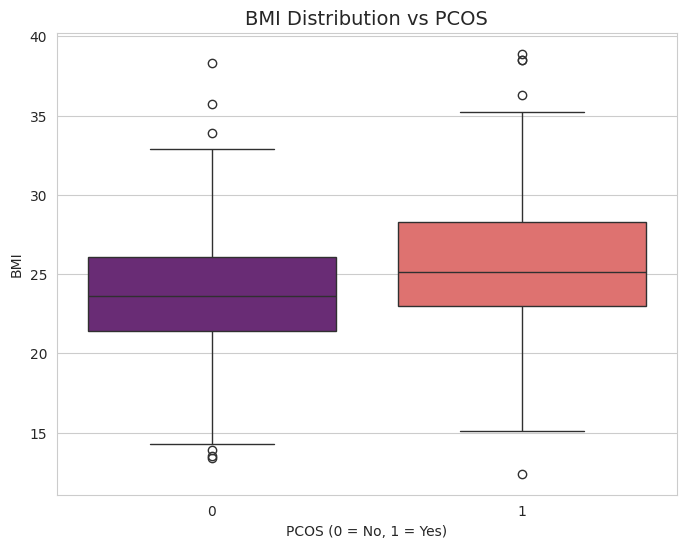

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='PCOS (Y/N)', y='BMI', data=df, palette='magma')

plt.title("BMI Distribution vs PCOS", fontsize=14)
plt.xlabel("PCOS (0 = No, 1 = Yes)")
plt.ylabel("BMI")
plt.show()

In [ ]:
X = df.drop('PCOS (Y/N)', axis=1)
y = df['PCOS (Y/N)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
# Keep feature names by wrapping the output in a DataFrame
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression:", accuracy_score(y_test, model.predict(X_test)))
print("Decision Tree:", accuracy_score(y_test, dt.predict(X_test)))
print("Random Forest:", accuracy_score(y_test, rf.predict(X_test)))

Accuracy: 0.7155963302752294
Logistic Regression: 0.8532110091743119
Decision Tree: 0.8623853211009175
Random Forest: 0.7155963302752294


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95        73
           1       0.97      0.83      0.90        36

    accuracy                           0.94       109
   macro avg       0.95      0.91      0.92       109
weighted avg       0.94      0.94      0.93       109



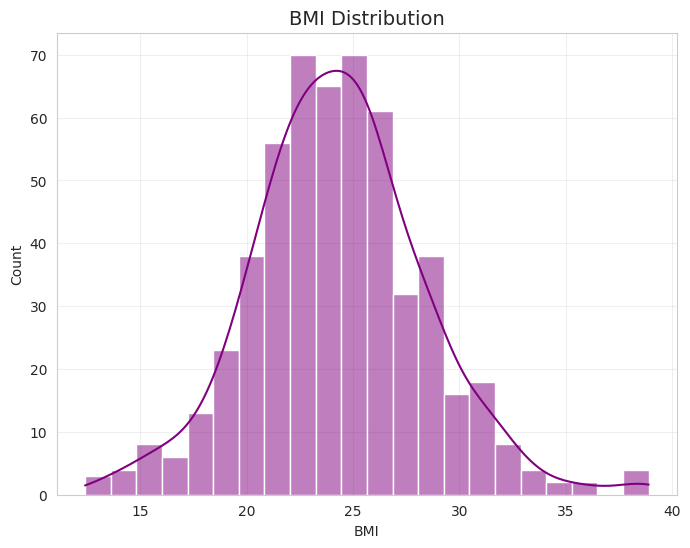

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df['BMI'], kde=True, color='purple', edgecolor='white')

plt.title("BMI Distribution", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_175/349097951.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PCOS (Y/N)', y='Weight gain(Y/N)', data=df, palette='husl')


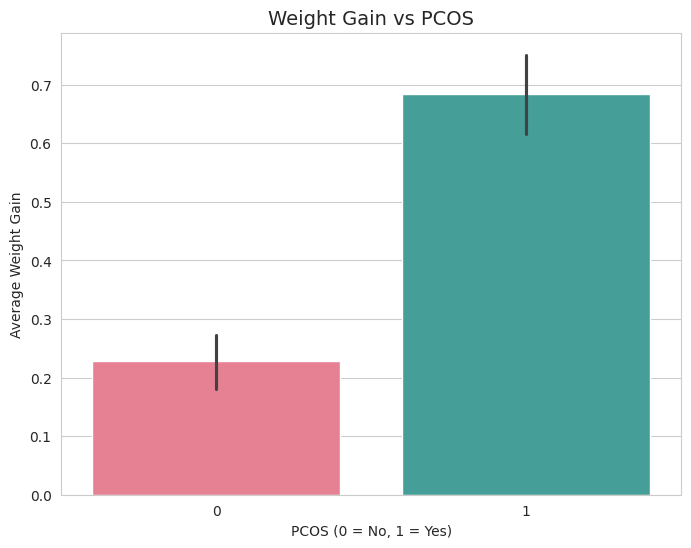

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(x='PCOS (Y/N)', y='Weight gain(Y/N)', data=df, palette='husl')
plt.title("Weight Gain vs PCOS", fontsize=14)
plt.xlabel("PCOS (0 = No, 1 = Yes)")
plt.ylabel("Average Weight Gain")
plt.show()

/tmp/ipykernel_175/3462708913.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='PCOS (Y/N)', y='BMI', data=df, palette='turbo', inner='quartile')   # also shows median & quartiles


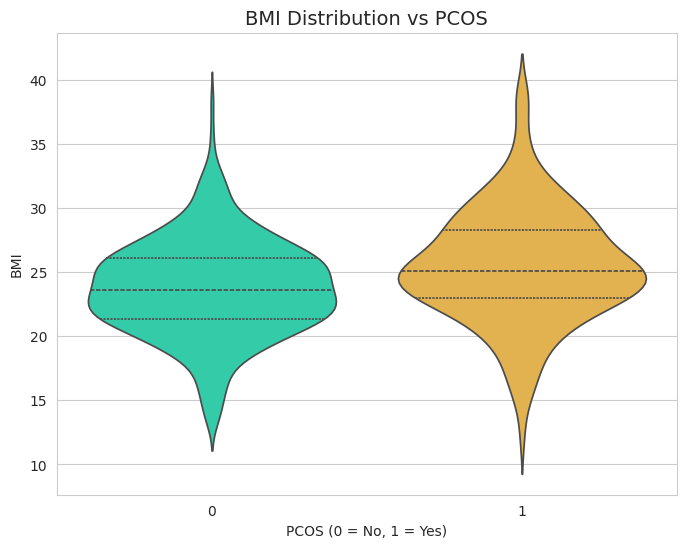

In [ ]:
plt.figure(figsize=(8,6))
sns.violinplot(x='PCOS (Y/N)', y='BMI', data=df, palette='turbo', inner='quartile')   # also shows median & quartiles

plt.title("BMI Distribution vs PCOS", fontsize=14)
plt.xlabel("PCOS (0 = No, 1 = Yes)")
plt.ylabel("BMI")
plt.show()

In [ ]:
def predict_pcos(input_data):
    import pandas as pd

    input_df = pd.DataFrame([input_data])
    input_df = input_df.apply(pd.to_numeric, errors='coerce')
    input_df.fillna(df.mean(), inplace=True)

    prediction = rf.predict(input_df)

    if prediction[0] == 1:
        return "PCOS Detected"
    else:
        return "No PCOS"